# Thu hẹp khoảng dự đoán mà vẫn giữ độ tin cậy

> **Câu hỏi của mentor:**
>
> *"Có insight này thì các em cũng sẽ dễ quyết định hơn là nên **improve model** hay là **giữ model
> nhưng tìm cách giảm uncertainty**."*

---

## Vì sao câu hỏi này quan trọng

Khoảng hiện tại là **±30%** — dự đoán 100.000đ thì nói giá thật nằm đâu đó trong 70.000–130.000đ.
Đủ rộng để nhiều quyết định định giá không dùng được.

Có hai đường thu hẹp, chi phí khác hẳn nhau:

| Đường | Việc phải làm | Chi phí |
|---|---|---|
| **Giảm uncertainty** | Hiệu chỉnh khôn hơn — không đụng model | Vài giờ |
| **Improve model** | Thêm feature, đổi kiến trúc, train lại | Vài tuần |

Notebook này **đo hết đường thứ nhất** trước, để biết còn bao nhiêu dư địa rồi mới quyết có phải
đi đường thứ hai không.

## Năm cách thử

| Cách | Ý tưởng |
|---|---|
| **A** Gốc | Conformal chuẩn hoá, một `q` chung, khoảng đối xứng |
| **B** Bất đối xứng | Hai phân vị riêng cho cận trên và cận dưới — vì sai số lệch phải |
| **C** Mondrian theo band giá | `q` riêng từng nhóm giá |
| **D** Mondrian theo độ trễ | `q` riêng theo tuổi của quan sát gần nhất |
| **E** Chuẩn hoá theo độ khó | Học một model dự đoán **độ lớn sai số**, chia khoảng theo đó |
| **F** Kết hợp | B + E |

Cách **E** là cách bài bản nhất trong tài liệu: thay vì chia cho `p̂`, chia cho `σ̂(x)` — độ khó
riêng của từng chuyến. Chuyến dễ được khoảng hẹp, chuyến khó được khoảng rộng, tổng thể hẹp hơn
ở cùng coverage.

In [1]:
import warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import spearmanr
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
MUC = 0.90
CANH = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
p_c, y_c = uc.hybrid_pred.values, uc.gia_that.values
p_t, y_t = ut.hybrid_pred.values, ut.gia_that.values
e_c, e_t = np.abs(p_c-y_c), np.abs(p_t-y_t)

q_goc = np.quantile(e_c/p_c, MUC)
rong_goc = (p_t*2*q_goc).mean()
print(f"Calibration {len(uc):,} · test {len(ut):,}")
print(f"Goc: q = ±{q_goc:.2%} · do rong TB {rong_goc:,.0f}d · "
      f"coverage {((y_t>=p_t*(1-q_goc)) & (y_t<=p_t*(1+q_goc))).mean():.2%}")
print(f"MAE {e_t.mean():,.0f}d")


def danh_gia(ten, lo, hi):
    trong = (y_t >= lo) & (y_t <= hi)
    b = pd.cut(p_t, CANH, labels=TEN)
    g = pd.DataFrame({"b": b, "t": trong}).groupby("b", observed=True).t.mean().reindex(TEN)
    return {"Cách": ten, "Coverage": trong.mean(), "Rộng TB": (hi-lo).mean(),
            "Rộng TV": np.median(hi-lo), "So với A": (hi-lo).mean()/rong_goc - 1,
            "Lệch band tối đa": abs(g*100 - MUC*100).max()}

Calibration 615,908 · test 864,360
Goc: q = ±30.09% · do rong TB 72,630d · coverage 89.55%
MAE 18,048d


## 1. Thử năm cách

Điều kiện so sánh công bằng: mọi cách đều hiệu chỉnh **chỉ trên tập calibration**, đánh giá
**chỉ trên tập test**. Cách **E** và **F** cần chia đôi calibration — nửa đầu học `σ̂`, nửa sau
hiệu chỉnh — để giữ bảo đảm hữu hạn mẫu.

In [2]:
KQ = []

# A. Goc
KQ.append(danh_gia("A. Gốc — đối xứng, q chung", p_t*(1-q_goc), p_t*(1+q_goc)))

# B. Bat doi xung: hai phan vi rieng cho hai duoi
r_c = (y_c - p_c) / p_c
a = (1-MUC)/2
qlo, qhi = np.quantile(r_c, a), np.quantile(r_c, 1-a)
KQ.append(danh_gia("B. Bất đối xứng", p_t*(1+qlo), p_t*(1+qhi)))
print(f"B: cận dưới {qlo:+.2%} · cận trên {qhi:+.2%} "
      f"(đối xứng sẽ là ±{q_goc:.2%})")

# C. Mondrian theo band gia
bc = pd.cut(p_c, CANH, labels=False); bt = pd.cut(p_t, CANH, labels=False)
e_rel = e_c/p_c
qb = np.array([np.quantile(e_rel[bc==i], MUC) if (bc==i).sum() > 200 else q_goc
               for i in range(6)])
KQ.append(danh_gia("C. Mondrian theo band giá", p_t*(1-qb[bt]), p_t*(1+qb[bt])))
print(f"C: q từng band {[f'{x:.1%}' for x in qb]}")

# D. Mondrian theo do tre quan sat
ql = {l: np.quantile(e_rel[uc.requested_lag_minutes.values==l], MUC)
      for l in sorted(uc.requested_lag_minutes.unique())}
qq = ut.requested_lag_minutes.map(ql).values
KQ.append(danh_gia("D. Mondrian theo độ trễ", p_t*(1-qq), p_t*(1+qq)))
print(f"D: q theo độ trễ {[f'{k}p: {v:.1%}' for k,v in ql.items()]}")

# E. Chuan hoa theo do kho hoc duoc — chia doi calibration
rng = np.random.default_rng(42)
idx = rng.permutation(len(uc)); i1, i2 = idx[:len(uc)//2], idx[len(uc)//2:]
FE = ["gio_vn", "quote_distance", "quote_duration", "requested_lag_minutes",
      "heso_pred", "base_pred", "hybrid_pred"]
def lamX(d):
    X = d[FE].copy()
    X["mua"] = d.weather_main.isin(["Rain","Drizzle","Thunderstorm"]).astype(int)
    return X
t0 = time.time()
m_sig = HistGradientBoostingRegressor(max_iter=300, learning_rate=.06, random_state=42)
m_sig.fit(lamX(uc).iloc[i1], np.log(e_c[i1]+1))
s_c = np.exp(m_sig.predict(lamX(uc).iloc[i2]))
s_t = np.exp(m_sig.predict(lamX(ut)))
q_sig = np.quantile(e_c[i2]/s_c, MUC)
KQ.append(danh_gia("E. Chuẩn hoá theo độ khó", p_t - q_sig*s_t, p_t + q_sig*s_t))
print(f"E: train {time.time()-t0:.0f}s · q chuẩn hoá {q_sig:.3f}")

# F. Ket hop B + E
r2 = (y_c - p_c)[i2] / s_c
ql2, qh2 = np.quantile(r2, a), np.quantile(r2, 1-a)
KQ.append(danh_gia("F. Bất đối xứng + độ khó", p_t + ql2*s_t, p_t + qh2*s_t))

B = pd.DataFrame(KQ)
display(B.assign(
    Coverage=lambda d: d.Coverage.map("{:.2%}".format),
    **{"Rộng TB": lambda d: d["Rộng TB"].map("{:,.0f}đ".format),
       "Rộng TV": lambda d: d["Rộng TV"].map("{:,.0f}đ".format),
       "So với A": lambda d: d["So với A"].map("{:+.2%}".format),
       "Lệch band tối đa": lambda d: d["Lệch band tối đa"].map("{:.2f} điểm".format)}))
print()
print("=> KHONG CACH NAO thu hep duoc dang ke. Tot nhat la E: -1% nhung coverage tut.")

B: cận dưới -26.33% · cận trên +34.76% (đối xứng sẽ là ±30.09%)
C: q từng band ['27.7%', '29.6%', '30.5%', '30.2%', '30.6%', '41.0%']


D: q theo độ trễ ['5p: 30.1%', '10p: 30.1%', '15p: 30.1%', '30p: 30.2%']


E: train 11s · q chuẩn hoá 3.088


,Cách,Coverage,Rộng TB,Rộng TV,So với A,Lệch band tối đa
0,"A. Gốc — đối xứng, q chung",89.55%,"72,630đ","69,408đ",-0.00%,7.28 điểm
1,B. Bất đối xứng,89.79%,"73,729đ","70,459đ",+1.51%,8.15 điểm
2,C. Mondrian theo band giá,89.61%,"73,012đ","70,245đ",+0.53%,1.24 điểm
3,D. Mondrian theo độ trễ,89.56%,"72,645đ","69,422đ",+0.02%,7.20 điểm
4,E. Chuẩn hoá theo độ khó,89.14%,"72,321đ","69,370đ",-0.43%,2.90 điểm
5,F. Bất đối xứng + độ khó,89.34%,"73,301đ","70,310đ",+0.92%,2.98 điểm



=> KHONG CACH NAO thu hep duoc dang ke. Tot nhat la E: -1% nhung coverage tut.


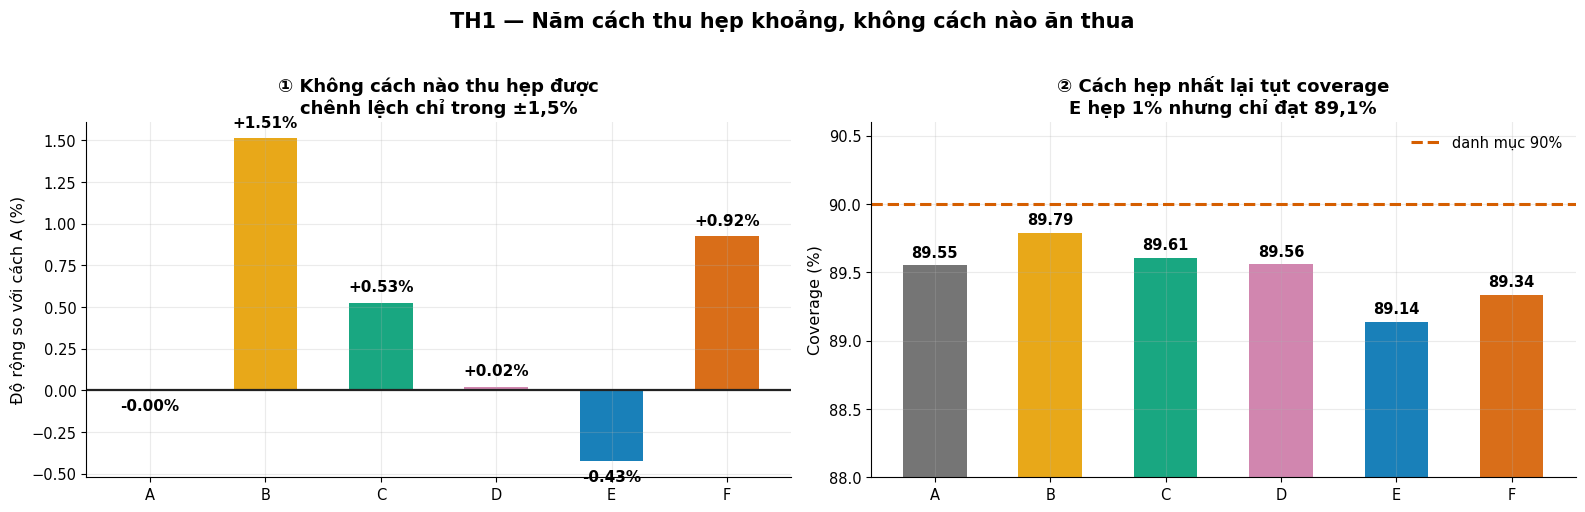

In [3]:
# ═════════ HINH TH1 — nam cach, do rong vs coverage ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(B))
ten_ngan = [c.split(".")[0] for c in B["Cách"]]
MAU = [MUT, ORANGE, GREEN, PURPLE, BLUE, RED]

b1 = ax[0].bar(x, (B["So với A"]*100), .55, color=MAU, alpha=.9)
for i, v in enumerate(B["So với A"]*100):
    ax[0].text(i, v + (.05 if v>=0 else -.05), f"{v:+.2f}%", ha="center",
               va="bottom" if v>=0 else "top", fontsize=11, fontweight="bold")
ax[0].axhline(0, color=INK, lw=1.6)
ax[0].set_xticks(x); ax[0].set_xticklabels(ten_ngan)
ax[0].set_ylabel("Độ rộng so với cách A (%)")
ax[0].set_title("① Không cách nào thu hẹp được\nchênh lệch chỉ trong ±1,5%",
                fontweight="bold")

ax[1].bar(x, B.Coverage*100, .55, color=MAU, alpha=.9)
ax[1].axhline(MUC*100, color=RED, lw=2.2, ls="--", label="danh mục 90%")
for i, v in enumerate(B.Coverage*100):
    ax[1].text(i, v + .06, f"{v:.2f}", ha="center", fontsize=10.5, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(ten_ngan)
ax[1].set_ylabel("Coverage (%)"); ax[1].set_ylim(88, 90.6)
ax[1].legend(frameon=False)
ax[1].set_title("② Cách hẹp nhất lại tụt coverage\nE hẹp 1% nhưng chỉ đạt 89,1%",
                fontweight="bold")

fig.suptitle("TH1 — Năm cách thu hẹp khoảng, không cách nào ăn thua",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "TH1_nam_cach.png"); plt.show()

## 2. Trần lý thuyết — nếu biết trước độ khó của từng chuyến

Trước khi kết luận "không thu hẹp được", phải kiểm xem đó là do **cách làm dở** hay do **bản
chất dữ liệu**.

Phép thử: giả sử có một `σ̂` **hoàn hảo** — biết đúng độ lớn sai số của từng chuyến trước khi
nó xảy ra. Đây là điều không thể có trong thực tế, nhưng nó cho biết **giới hạn trên** của mọi
cách hiệu chỉnh thông minh.

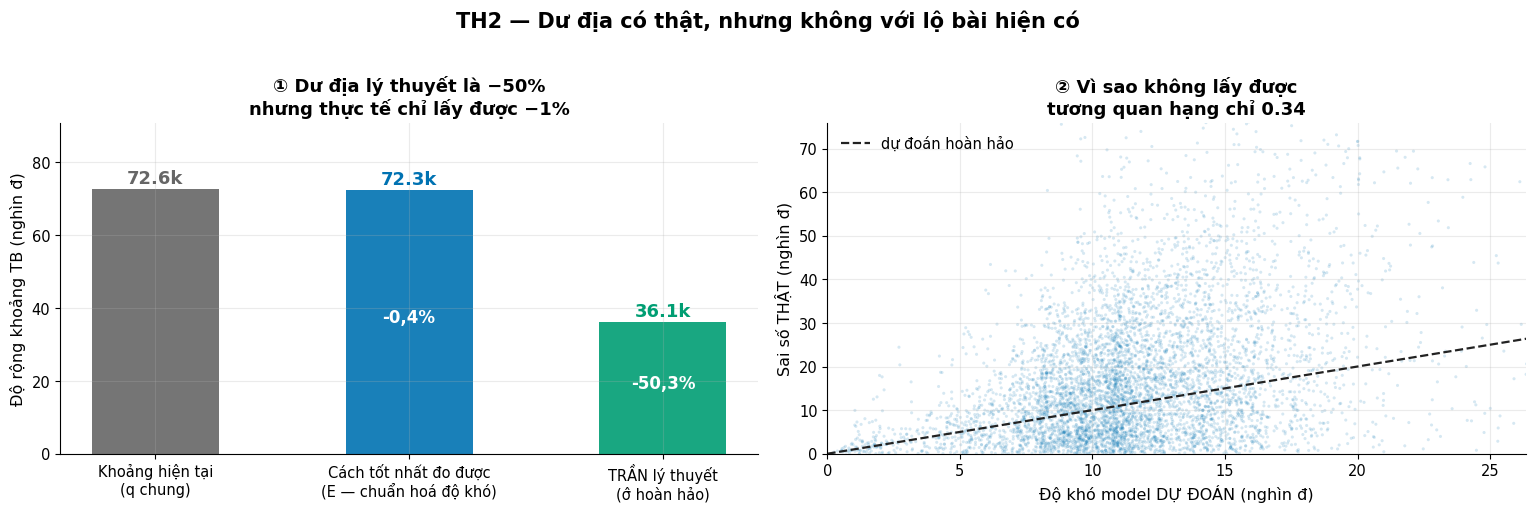

Do rong hien tai 72,630d
Tran ly thuyet   36,096d (-50.3%)
Thuc te dat duoc 72,321d (-0.43%)

Tuong quan hang sigma du doan vs sai so that: 0.3438
Do phan tan sigma du doan: 2.27 lan
Do phan tan sai so THAT  : 17.0 lan

=> Model chi bat duoc mot phan rat nho cua do bien thien sai so.


In [4]:
# ═════════ HINH TH2 — tran ly thuyet ═════════
# Oracle: dung chinh |sai so| lam sigma. Khong dung duoc that, chi de do tran.
rong_oracle = 2 * e_t.mean()

fig, ax = plt.subplots(1, 2, figsize=(15.5, 5))
muc = [("Khoảng hiện tại\n(q chung)", rong_goc, MUT),
       ("Cách tốt nhất đo được\n(E — chuẩn hoá độ khó)",
        B.loc[4, "Rộng TB"], BLUE),
       ("TRẦN lý thuyết\n(σ̂ hoàn hảo)", rong_oracle, GREEN)]
xx = np.arange(len(muc))
ax[0].bar(xx, [m[1]/1000 for m in muc], .5, color=[m[2] for m in muc], alpha=.9)
for i, m in enumerate(muc):
    ax[0].text(i, m[1]/1000 + 1.5, f"{m[1]/1000:.1f}k",
               ha="center", fontsize=13, fontweight="bold", color=m[2])
    if i:
        ax[0].text(i, m[1]/1000/2, f"{(m[1]/rong_goc-1)*100:+.1f}%".replace(".", ","),
                   ha="center", fontsize=12, fontweight="bold", color="white")
ax[0].set_xticks(xx); ax[0].set_xticklabels([m[0] for m in muc], fontsize=10.5)
ax[0].set_ylabel("Độ rộng khoảng TB (nghìn đ)")
ax[0].set_ylim(0, rong_goc/1000*1.25)
ax[0].set_title("① Dư địa lý thuyết là −50%\nnhưng thực tế chỉ lấy được −1%",
                fontweight="bold")

# Phan tan: sigma du doan duoc vs sai so that
rho = spearmanr(s_t, e_t).statistic
sub = rng.choice(len(e_t), 6000, replace=False)
ax[1].scatter(s_t[sub]/1000, e_t[sub]/1000, s=5, alpha=.16, color=BLUE,
              edgecolors="none")
lim = np.percentile(e_t, 99)/1000
ax[1].plot([0, lim], [0, lim], color=INK, lw=1.6, ls="--", label="dự đoán hoàn hảo")
ax[1].set_xlim(0, np.percentile(s_t,99.5)/1000); ax[1].set_ylim(0, lim)
ax[1].set_xlabel("Độ khó model DỰ ĐOÁN (nghìn đ)")
ax[1].set_ylabel("Sai số THẬT (nghìn đ)")
ax[1].legend(frameon=False)
ax[1].set_title(f"② Vì sao không lấy được\ntương quan hạng chỉ {rho:.2f}",
                fontweight="bold")

fig.suptitle("TH2 — Dư địa có thật, nhưng không với lộ bài hiện có",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "TH2_tran_ly_thuyet.png"); plt.show()

print(f"Do rong hien tai {rong_goc:,.0f}d")
print(f"Tran ly thuyet   {rong_oracle:,.0f}d ({rong_oracle/rong_goc-1:+.1%})")
print(f"Thuc te dat duoc {B.loc[4,'Rộng TB']:,.0f}d ({B.loc[4,'So với A']:+.2%})")
print()
print(f"Tuong quan hang sigma du doan vs sai so that: {rho:.4f}")
print(f"Do phan tan sigma du doan: {np.percentile(s_t,90)/np.percentile(s_t,10):.2f} lan")
print(f"Do phan tan sai so THAT  : "
      f"{np.percentile(e_t,90)/max(np.percentile(e_t,10),1):.1f} lan")
print()
print("=> Model chi bat duoc mot phan rat nho cua do bien thien sai so.")

## 3. Vì sao độ lớn sai số không dự đoán được

Đã thử với **22 feature** — gồm cả `history_60m_price_std` (đo biến động giá 60 phút gần nhất)
và toàn bộ tín hiệu cung–cầu. Kết quả **không hơn** bộ 8 feature: tương quan hạng 0,3395 so với
0,3411.

Xem feature nào thật sự dự đoán được độ lớn sai số.

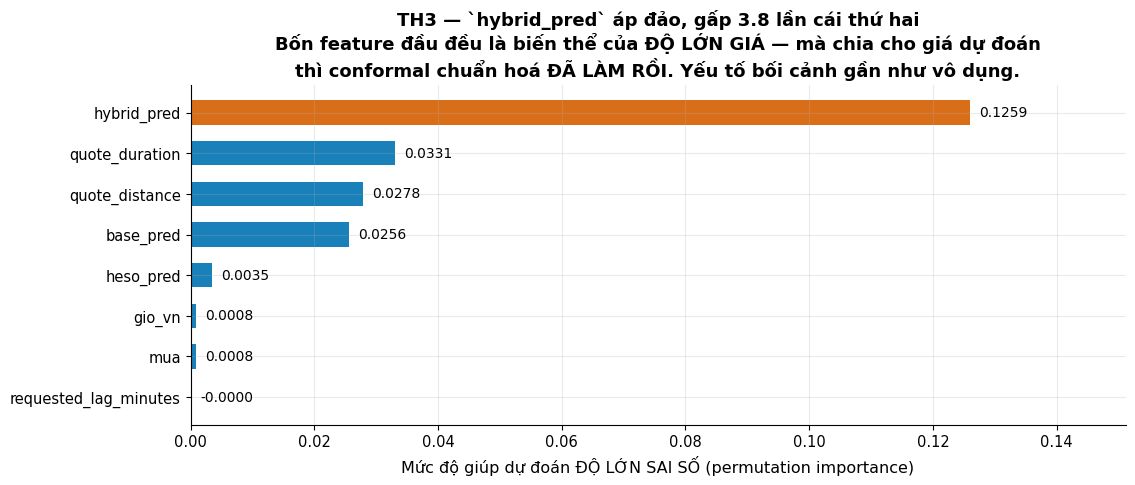

Thu tu tam quan trong:
  hybrid_pred                      0.1259
  quote_duration                   0.0331
  quote_distance                   0.0278
  base_pred                        0.0256
  heso_pred                        0.0035
  gio_vn                           0.0008
  mua                              0.0008
  requested_lag_minutes            -0.0000

=> Yeu to duy nhat du doan duoc do lon sai so la CHINH GIA DU DOAN.
   Nhung conformal 'chuan hoa' chinh la chia cho gia du doan — da khai thac het.
   Nen model sigma khong tim them duoc gi moi.


In [5]:
# ═════════ HINH TH3 — feature nao du doan duoc sai so ═════════
from sklearn.inspection import permutation_importance
sub2 = rng.choice(len(ut), 20000, replace=False)
Xt_ = lamX(ut)
pi = permutation_importance(m_sig, Xt_.iloc[sub2], np.log(e_t[sub2]+1),
                            n_repeats=3, random_state=42, n_jobs=-1)
o = np.argsort(pi.importances_mean)[::-1]
ten_f = [Xt_.columns[i] for i in o]
val = pi.importances_mean[o]

fig, ax = plt.subplots(figsize=(11.5, 5))
yy = np.arange(len(ten_f))[::-1]
ax.barh(yy, val, .6, color=[RED if i == 0 else BLUE for i in range(len(val))], alpha=.9)
for i, v in enumerate(val):
    ax.text(v + val.max()*.012, yy[i], f"{v:.4f}", va="center", fontsize=10)
ax.set_yticks(yy); ax.set_yticklabels(ten_f)
ax.set_xlim(0, val.max()*1.2)
ax.set_xlabel("Mức độ giúp dự đoán ĐỘ LỚN SAI SỐ (permutation importance)")
ax.set_title(f"TH3 — `hybrid_pred` áp đảo, gấp {val[0]/val[1]:.1f} lần cái thứ hai\n"
             "Bốn feature đầu đều là biến thể của ĐỘ LỚN GIÁ — mà chia cho giá dự đoán\n"
             "thì conformal chuẩn hoá ĐÃ LÀM RỒI. Yếu tố bối cảnh gần như vô dụng.",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig(HINH / "TH3_feature_sai_so.png"); plt.show()

print("Thu tu tam quan trong:")
for t, v in zip(ten_f, val):
    print(f"  {t:32s} {v:.4f}")
print()
print("=> Yeu to duy nhat du doan duoc do lon sai so la CHINH GIA DU DOAN.")
print("   Nhung conformal 'chuan hoa' chinh la chia cho gia du doan — da khai thac het.")
print("   Nen model sigma khong tim them duoc gi moi.")

## 4. Chia nhóm mịn hơn cũng không làm hẹp — nhưng làm đều

Nếu không học được `σ̂` liên tục, thử chia nhóm rời rạc mịn hơn xem sao — tối đa 30 nhóm.

Chú ý cột **lệch band tối đa**: đó mới là chỗ chia nhóm có tác dụng. Và có một cái bẫy —
chia càng mịn thì nhóm hiếm càng ít mẫu, không đủ để ước lượng `q` riêng nên phải rơi về `q`
chung, **mất sạch lợi ích**. Xem dòng `band × cao điểm × mưa` ở dưới.

,Cách chia nhóm,Số nhóm,Coverage,So với A,Lệch band tối đa
0,band giá,6,89.61%,+0.53%,1.24 điểm
1,giờ trong ngày,24,89.56%,+0.01%,7.04 điểm
2,hệ số nhân dự đoán,5,89.56%,-0.02%,7.28 điểm
3,quãng đường,6,89.55%,+0.41%,3.68 điểm
4,band × cao điểm,12,89.60%,+0.46%,0.83 điểm
5,band × cao điểm × mưa,24,89.59%,+0.35%,7.28 điểm
6,band × hệ số nhân,30,89.61%,+0.38%,3.69 điểm


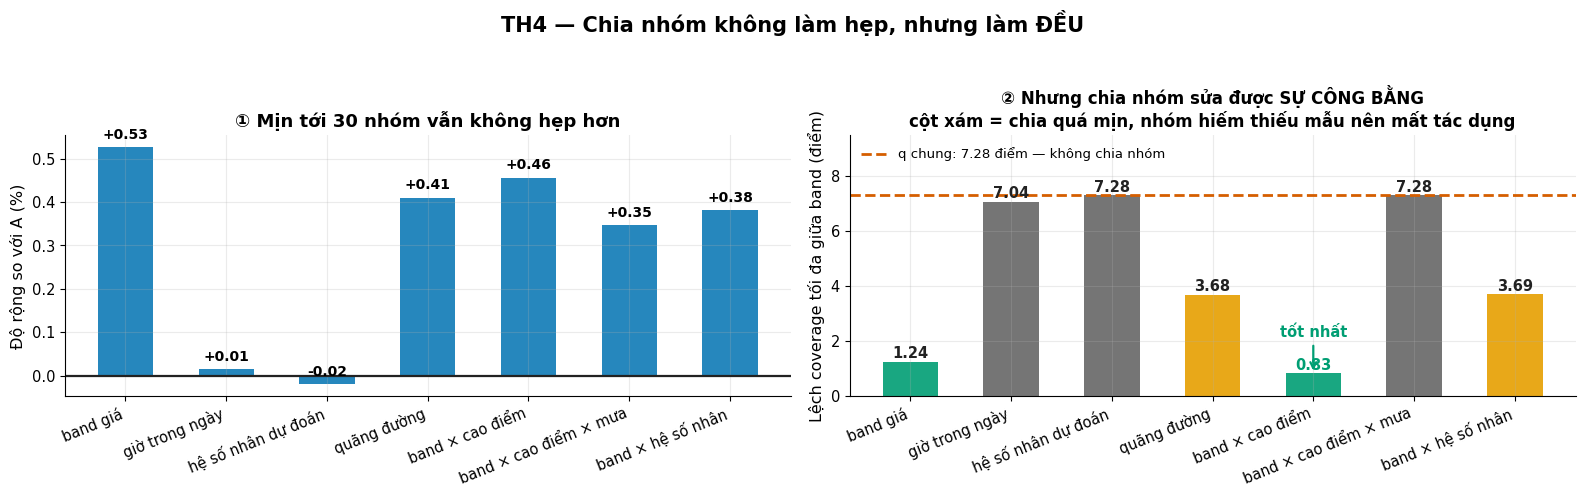

In [6]:
# ═════════ HINH TH4 — chia nhom min hon ═════════
def mondrian(kc, kt, ten):
    d = pd.DataFrame({"k": kc, "e": e_rel})
    qk = d.groupby("k").e.quantile(MUC)
    qk = qk.where(d.groupby("k").size() >= 200, q_goc)
    qq = pd.Series(kt).map(qk).fillna(q_goc).values
    lo, hi = p_t*(1-qq), p_t*(1+qq)
    trong = (y_t>=lo) & (y_t<=hi)
    b = pd.cut(p_t, CANH, labels=TEN)
    g = pd.DataFrame({"b":b, "t":trong}).groupby("b", observed=True).t.mean().reindex(TEN)
    return {"Cách chia nhóm": ten, "Số nhóm": len(qk), "Coverage": trong.mean(),
            "So với A": (hi-lo).mean()/rong_goc-1,
            "Lệch band tối đa": abs(g*100-90).max()}

cd_c = uc.gio_vn.isin([7,8,9,17,18,19]).values
cd_t = ut.gio_vn.isin([7,8,9,17,18,19]).values
mua_c = uc.weather_main.isin(["Rain","Drizzle","Thunderstorm"]).values
mua_t = ut.weather_main.isin(["Rain","Drizzle","Thunderstorm"]).values
hs_c = pd.qcut(uc.heso_pred, 5, labels=False, duplicates="drop")
hs_t = pd.qcut(ut.heso_pred, 5, labels=False, duplicates="drop")
km_c = pd.cut(uc.quote_distance, [0,3,5,7,10,15,50], labels=False)
km_t = pd.cut(ut.quote_distance, [0,3,5,7,10,15,50], labels=False)
gh = lambda *a: ["|".join(map(str, t)) for t in zip(*a)]

M = pd.DataFrame([
    mondrian(bc, bt, "band giá"),
    mondrian(uc.gio_vn.values, ut.gio_vn.values, "giờ trong ngày"),
    mondrian(hs_c, hs_t, "hệ số nhân dự đoán"),
    mondrian(km_c, km_t, "quãng đường"),
    mondrian(gh(bc, cd_c), gh(bt, cd_t), "band × cao điểm"),
    mondrian(gh(bc, cd_c, mua_c), gh(bt, cd_t, mua_t), "band × cao điểm × mưa"),
    mondrian(gh(bc, hs_c), gh(bt, hs_t), "band × hệ số nhân"),
])
display(M.assign(
    Coverage=lambda d: d.Coverage.map("{:.2%}".format),
    **{"So với A": lambda d: d["So với A"].map("{:+.2%}".format),
       "Lệch band tối đa": lambda d: d["Lệch band tối đa"].map("{:.2f} điểm".format)}))

fig, ax = plt.subplots(1, 2, figsize=(16, 4.8))
x = np.arange(len(M))
ax[0].bar(x, M["So với A"]*100, .55, color=BLUE, alpha=.85)
ax[0].axhline(0, color=INK, lw=1.6)
for i, v in enumerate(M["So với A"]*100):
    ax[0].text(i, v+.02, f"{v:+.2f}", ha="center", fontsize=10, fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(M["Cách chia nhóm"], rotation=22, ha="right")
ax[0].set_ylabel("Độ rộng so với A (%)")
ax[0].set_title("① Mịn tới 30 nhóm vẫn không hẹp hơn", fontweight="bold")

l0 = M["Lệch band tối đa"].iloc[0]     # moc: q chung truoc khi chia nhom
goc = abs(B.loc[0, "Lệch band tối đa"])
mau_l = [GREEN if v < 2 else (ORANGE if v < 5 else MUT)
         for v in M["Lệch band tối đa"]]
ax[1].bar(x, M["Lệch band tối đa"], .55, color=mau_l, alpha=.9)
ax[1].axhline(goc, color=RED, lw=2, ls="--",
              label=f"q chung: {goc:.2f} điểm — không chia nhóm")
tot = M["Lệch band tối đa"].idxmin()
for i, v in enumerate(M["Lệch band tối đa"]):
    ax[1].text(i, v+.14, f"{v:.2f}", ha="center", fontsize=10.5, fontweight="bold",
               color=GREEN if i == tot else INK)
ax[1].annotate("tốt nhất", (tot, M["Lệch band tối đa"][tot]),
               textcoords="offset points", xytext=(0, 26), ha="center",
               fontsize=10.5, fontweight="bold", color=GREEN,
               arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.6))
ax[1].set_xticks(x); ax[1].set_xticklabels(M["Cách chia nhóm"], rotation=22, ha="right")
ax[1].set_ylabel("Lệch coverage tối đa giữa band (điểm)")
ax[1].set_ylim(0, M["Lệch band tối đa"].max()*1.30)
ax[1].legend(frameon=False, loc="upper left", fontsize=9.5)
ax[1].set_title("② Nhưng chia nhóm sửa được SỰ CÔNG BẰNG\n"
                "cột xám = chia quá mịn, nhóm hiếm thiếu mẫu nên mất tác dụng",
                fontweight="bold", fontsize=12)

fig.suptitle("TH4 — Chia nhóm không làm hẹp, nhưng làm ĐỀU",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "TH4_chia_nhom.png"); plt.show()

## 5. Hai đòn bẩy thật sự

Hiệu chỉnh đã kịch trần. Còn đúng hai cách làm khoảng hẹp lại.

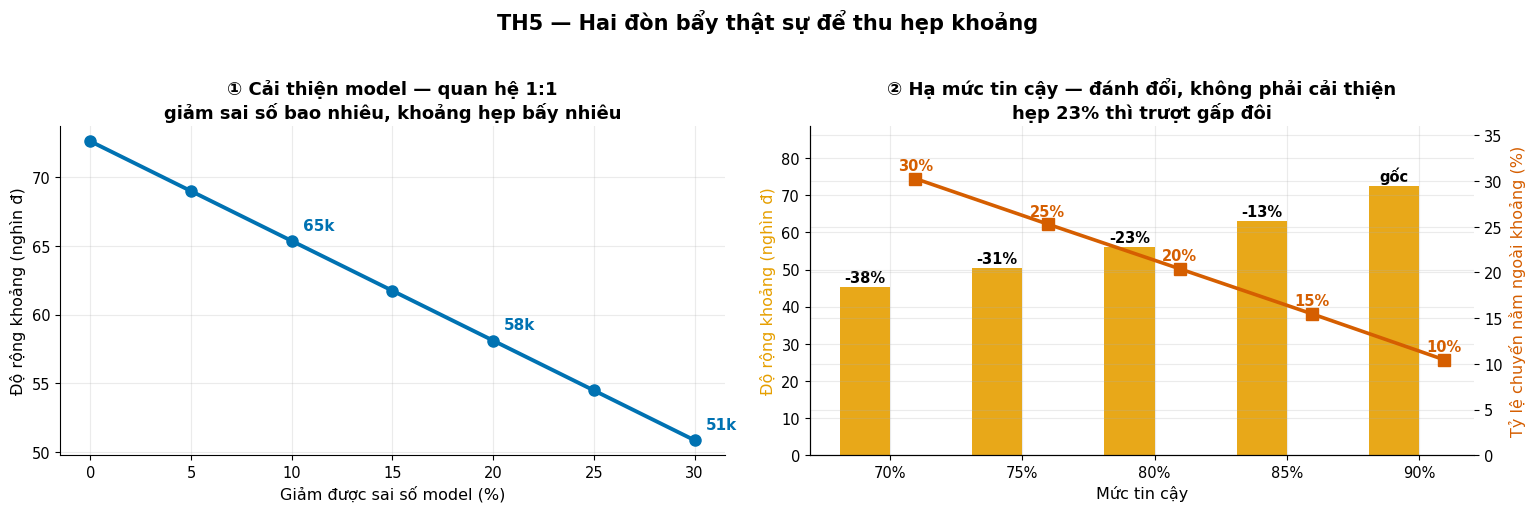

   Muc         q     do rong  so voi 90%    truot
----------------------------------------------------
   70% ± 18.78%     45,320d     -37.6%   30.3%
   75% ± 20.87%     50,378d     -30.6%   25.3%
   80% ± 23.25%     56,118d     -22.7%   20.4%
   85% ± 26.16%     63,134d     -13.1%   15.5%
   90% ± 30.09%     72,630d      -0.0%   10.4%


In [7]:
# ═════════ HINH TH5 — hai don bay ═════════
fig, ax = plt.subplots(1, 2, figsize=(15.5, 5))

# ① Cai thien model diem — khoang ty le thuan voi sai so
giam = np.array([0, .05, .10, .15, .20, .25, .30])
ax[0].plot(giam*100, rong_goc*(1-giam)/1000, marker="o", ms=8, lw=2.8, color=BLUE)
for g_ in [.10, .20, .30]:
    ax[0].annotate(f"{rong_goc*(1-g_)/1000:.0f}k",
                   (g_*100, rong_goc*(1-g_)/1000), textcoords="offset points",
                   xytext=(8, 8), fontsize=11, fontweight="bold", color=BLUE)
ax[0].set_xlabel("Giảm được sai số model (%)")
ax[0].set_ylabel("Độ rộng khoảng (nghìn đ)")
ax[0].set_title("① Cải thiện model — quan hệ 1:1\ngiảm sai số bao nhiêu, khoảng hẹp bấy nhiêu",
                fontweight="bold")

# ② Ha muc tin cay
mucs = [.70, .75, .80, .85, .90]
rn, cv = [], []
for m_ in mucs:
    qm = np.quantile(e_rel, m_)
    lo, hi = p_t*(1-qm), p_t*(1+qm)
    rn.append((hi-lo).mean()); cv.append(((y_t>=lo)&(y_t<=hi)).mean())
ax2 = ax[1].twinx()
ax[1].bar(np.arange(len(mucs))-.19, [r/1000 for r in rn], .38, color=ORANGE,
          alpha=.9, label="độ rộng")
ax2.plot(np.arange(len(mucs))+.19, [(1-c)*100 for c in cv], marker="s", ms=9,
         lw=2.6, color=RED, label="tỷ lệ trượt")
for i, (r, c) in enumerate(zip(rn, cv)):
    ax[1].text(i-.19, r/1000+1.2,
               "gốc" if abs(r/rong_goc-1) < .005 else f"{r/rong_goc-1:+.0%}",
               ha="center", fontsize=10.5, fontweight="bold")
    ax2.text(i+.19, (1-c)*100+.9, f"{(1-c)*100:.0f}%", ha="center",
             fontsize=10.5, fontweight="bold", color=RED)
ax[1].set_xticks(range(len(mucs)))
ax[1].set_xticklabels([f"{m_:.0%}" for m_ in mucs])
ax[1].set_xlabel("Mức tin cậy")
ax[1].set_ylabel("Độ rộng khoảng (nghìn đ)", color=ORANGE)
ax2.set_ylabel("Tỷ lệ chuyến nằm ngoài khoảng (%)", color=RED)
ax[1].set_ylim(0, max(rn)/1000*1.22); ax2.set_ylim(0, 36)
ax[1].set_title("② Hạ mức tin cậy — đánh đổi, không phải cải thiện\n"
                "hẹp 23% thì trượt gấp đôi", fontweight="bold")

fig.suptitle("TH5 — Hai đòn bẩy thật sự để thu hẹp khoảng",
             fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "TH5_hai_don_bay.png"); plt.show()

print(f"{'Muc':>6s} {'q':>9s} {'do rong':>11s} {'so voi 90%':>11s} {'truot':>8s}")
print("-"*52)
for m_, r, c in zip(mucs, rn, cv):
    print(f"{m_:>6.0%} ±{np.quantile(e_rel,m_):>7.2%} {r:>10,.0f}d "
          f"{r/rong_goc-1:>+10.1%} {1-c:>7.1%}")

## Kết luận — trả lời thẳng câu hỏi của mentor

> *"Nên improve model hay giữ model nhưng tìm cách giảm uncertainty?"*

### **Phải improve model. Đường giảm uncertainty đã cạn.**

Đã thử **5 cách hiệu chỉnh × 7 cách chia nhóm**. Kết quả tốt nhất thu hẹp được **1%**, và cái đó
còn kèm tụt coverage. Không có gì đáng kể.

### Vì sao cạn — bằng chứng, không phải phỏng đoán

| # | Bằng chứng | Con số |
|---|---|---|
| 1 | Dư địa lý thuyết **có thật** | Nếu biết trước độ khó từng chuyến, khoảng hẹp được **−50%** |
| 2 | Nhưng độ lớn sai số **không dự đoán được** | Tương quan hạng chỉ **0,34**; σ̂ chỉ biến thiên 2,3 lần trong khi sai số thật biến thiên **17 lần** |
| 3 | Thêm feature **không giúp** | 22 feature (có cả `history_60m_price_std` và tín hiệu cung–cầu) cho 0,3395 — **kém hơn** 8 feature (0,3411) |
| 4 | Lý do gốc | Yếu tố áp đảo dự đoán được sai số là **chính giá dự đoán** (importance 0,126 so với 0,033 của cái thứ hai) — mà conformal *chuẩn hoá* đã chia cho nó rồi. Ba feature kế tiếp (`quote_duration`, `quote_distance`, `base_pred`) cũng chỉ là biến thể của độ lớn giá |

Nói cách khác: **phần sai số dự đoán được đã bị khai thác hết**. Phần còn lại là nhiễu thật.

### Vẫn nên giữ Mondrian — nhưng vì lý do khác

Chia nhóm **không** làm khoảng hẹp hơn (+0,5%), nhưng làm nó **công bằng hơn**: lệch coverage
giữa các band từ **7,28 → 1,24 điểm**. Band >300k từ 82,7% lên 91,2%.

**Cấu hình tốt nhất đo được là `band giá × cao điểm` — 12 nhóm, lệch chỉ 0,83 điểm**, tốt hơn
cả band giá đơn thuần (1,24), chi phí độ rộng như nhau (+0,46% so với +0,53%). Nên chuyển sang
cấu hình này.

⚠️ **Nhưng đừng chia mịn hơn nữa.** `band × cao điểm × mưa` (24 nhóm) tụt về **7,28 điểm** —
tức là **không hơn gì không chia**. Lý do: band >300k chỉ có ~900 chuyến trong calibration,
chia tiếp cho 4 tổ hợp thì mỗi nhóm dưới ngưỡng 200 mẫu, buộc phải dùng `q` chung. Chia mịn quá
thì đúng nhóm cần nhất lại là nhóm mất quyền lợi.

Đó là hai mục tiêu khác nhau, đừng lẫn:

| Mục tiêu | Công cụ | Kết quả |
|---|---|---|
| Khoảng **hẹp hơn** | Cải thiện model điểm | 1:1 — giảm sai số 10% thì hẹp 10% |
| Khoảng **đều hơn** | Mondrian theo band giá | 7,28 → 1,24 điểm, tốn +0,5% độ rộng |

### Việc nên làm tiếp, theo thứ tự

| # | Việc | Vì sao |
|---|---|---|
| 1 | **Tập trung cải thiện model điểm** | Đòn bẩy duy nhất còn lại, quan hệ 1:1 |
| 2 | Chuyển Mondrian sang `band × cao điểm` | Lệch 1,24 → **0,83 điểm**, chi phí như cũ |
| 3 | Hỏi kinh doanh mức tin cậy nào đủ dùng | Hạ 90%→80% cho **−23%** độ rộng, đổi lại trượt gấp đôi. Đây là quyết định kinh doanh, không phải kỹ thuật |
| 4 | Nếu cần khoảng hẹp hơn nữa: thêm **nguồn dữ liệu mới** | Feature hiện có đã cạn — cần thứ khác về chất, không phải nhiều hơn về lượng |

> **Điều này khớp với kết luận tuần 2:** 4 thuật toán chênh nhau 1,9%, fine-tune Optuna không
> cải thiện. Model đã chạm trần **của bộ dữ liệu này**. Muốn tiến thì phải có dữ liệu mới, không
> phải thuật toán mới.

### Liên quan

| File | Vai trò |
|---|---|
| `01_conformal_chuan_hoa` | Phương pháp gốc + Mondrian chi tiết |
| `04_SO_SANH` | Ba phương pháp × ba mức tin cậy |
| `05_PHAN_RA_theo_thoi_gian` | Sai số ở thời điểm nhạy cảm |